Starting CAVI optimization...
Iteration 1/1000, Change in m_u: 6617365655.874678
Iteration 2/1000, Change in m_u: 0.102389
Iteration 3/1000, Change in m_u: 0.083302
Iteration 4/1000, Change in m_u: 0.054457
Iteration 5/1000, Change in m_u: 0.039804
Iteration 6/1000, Change in m_u: 0.030068
Iteration 7/1000, Change in m_u: 0.025017
Iteration 8/1000, Change in m_u: 0.020688
Iteration 9/1000, Change in m_u: 0.015858
Iteration 10/1000, Change in m_u: 0.011325
Iteration 11/1000, Change in m_u: 0.007672
Iteration 12/1000, Change in m_u: 0.004945
Iteration 13/1000, Change in m_u: 0.003034
Iteration 14/1000, Change in m_u: 0.001787
Iteration 15/1000, Change in m_u: 0.001022
Iteration 16/1000, Change in m_u: 0.000572
Iteration 17/1000, Change in m_u: 0.000317
Iteration 18/1000, Change in m_u: 0.000174
Iteration 19/1000, Change in m_u: 0.000095
Iteration 20/1000, Change in m_u: 0.000052
Iteration 21/1000, Change in m_u: 0.000028
Iteration 22/1000, Change in m_u: 0.000015
Iteration 23/1000, Chang

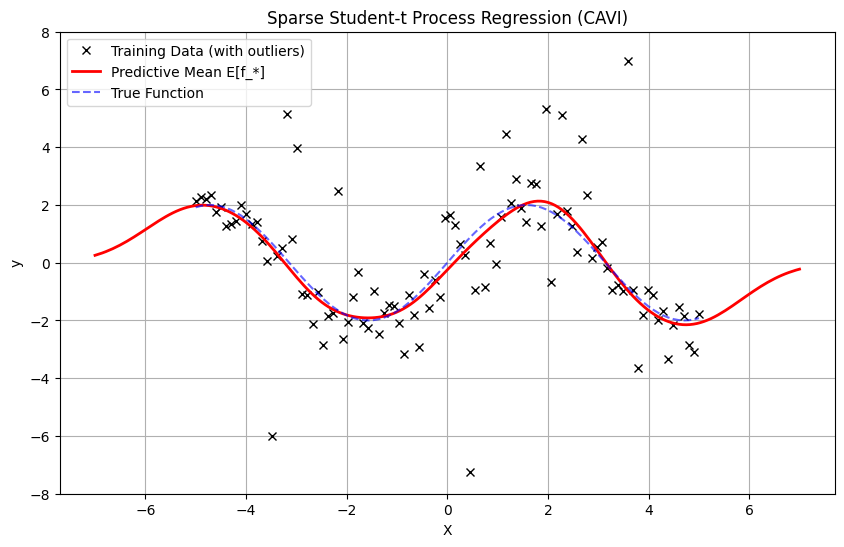

In [3]:
import torch

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionCAVI:
    """
    PyTorch implementation of CAVI for Student-t Process Regression
    with a Student-t Likelihood, based on the provided document.

    This version is improved with Cholesky decomposition for better numerical
    stability and efficiency, inspired by best practices in GP implementations.
    """
    def __init__(self, X, y, M=20, nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0):
        """
        Initializes the model and variational parameters. [cite: 133]

        Args:
            X (torch.Tensor): Training inputs (N x D).
            y (torch.Tensor): Training outputs (N x 1).
            M (int): Number of inducing points.
            nu_f (float): Degrees of freedom for the TP prior. [cite: 13]
            nu_epsilon (float): Degrees of freedom for the likelihood. [cite: 19]
            sigma_sq (float): Scale parameter for the likelihood noise. [cite: 19]
        """
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # Initialize hyperparameters [cite: 133]
        self.nu_f = torch.tensor(nu_f)
        self.nu_epsilon = torch.tensor(nu_epsilon)
        self.sigma_sq = torch.tensor(sigma_sq)
        self.kernel = rbf_kernel

        # Initialize inducing points Z by selecting M random points from X
        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        # Pre-compute kernel matrices
        self.K_ZZ = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        # --- MODIFIED: Use Cholesky decomposition instead of direct inverse ---
        self.L_ZZ = torch.linalg.cholesky(self.K_ZZ)
        self.K_XZ = self.kernel(self.X, self.Z)
        
        # --- Initialize Variational Parameters --- [cite: 133]
        # q(u) = N(m_u, S_u)
        self.m_u = torch.zeros(self.M, 1) # [cite: 47]
        self.S_u = torch.eye(self.M)       # [cite: 47]

        # q(r) = Gamma(alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0) # [cite: 49]
        self.beta_r = torch.tensor(1.0)  # [cite: 49]

        # q(lambda_i) = Gamma(alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N) # [cite: 51]
        self.beta_lambda = torch.ones(self.N)  # [cite: 51]

    def _update_q_lambda(self):
        """
        Updates the variational parameters for q(lambda_i) for all i=1..N.
        This corresponds to lines 5-8 in Algorithm 1. [cite: 137, 143]
        """
        # 1. Compute expected squared error E_q[(y_i - f_i)^2] [cite: 141]
        # E_q[(y_i - f_i)^2] = (y_i - E[f_i])^2 + Var(f_i) [cite: 112]
        
        # --- MODIFIED: Use cholesky_solve for stability ---
        # Calculate E[f_i] = k_i,Z * K_ZZ^-1 * m_u [cite: 114]
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u

        # Calculate Var(f_i) [cite: 116, 118]
        # We need E[r^-1] = beta_r / (alpha_r - 1) for alpha_r > 1 [cite: 119]
        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r # Fallback for stability at initialization
        
        k_ii = torch.diag(self.kernel(self.X, self.X))

        # --- MODIFIED: Efficiently compute diagonals without forming K_ZZ_inv ---
        # Term 1: diag(K_XZ @ K_ZZ^-1 @ K_ZX)
        # Let V = L_ZZ^-1 @ K_ZX. Then this term is diag(V.T @ V) = sum(V^2, dim=0)
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        # Term 2: diag(K_XZ @ K_ZZ^-1 @ S_u @ K_ZZ^-1 @ K_ZX)
        # Let A = K_XZ @ K_ZZ^-1 and L_S be the Cholesky of S_u.
        # This term is diag(A @ L_S @ L_S.T @ A.T) = sum((A @ L_S)^2, dim=1)
        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M) * 1e-9) # Jitter for stability
        B = A_T.T @ L_S
        var_f_term2 = (B**2).sum(dim=1)
        
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        # 2. Update alpha_lambda and beta_lambda using Eq. (1) and (2) [cite: 62, 64]
        self.alpha_lambda = self.nu_epsilon / 2.0 + 0.5
        self.beta_lambda = self.nu_epsilon / 2.0 + (0.5 / self.sigma_sq) * expected_sq_error.clamp(min=1e-9)

    def _update_q_r(self):
        """
        Updates the variational parameters for the global precision q(r).
        This corresponds to lines 10-12 in Algorithm 1. [cite: 146, 150]
        """
        # --- MODIFIED: Use cholesky_solve for stability ---
        # 1. Compute E_q(u)[u^T * K_ZZ^-1 * u] [cite: 148]
        # Using formula: Tr(K_ZZ^-1 * S_u) + m_u^T * K_ZZ^-1 * m_u [cite: 122]
        K_ZZ_inv_S_u = torch.cholesky_solve(self.S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        mean_term = self.m_u.T @ K_ZZ_inv_m_u
        
        expected_u_quadratic_form = trace_term + mean_term

        # 2. Update alpha_r and beta_r using Eq. (3) and (4) [cite: 67, 68]
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self):
        """
        Updates the variational parameters for q(u).
        This corresponds to lines 15-17 in Algorithm 1. [cite: 159, 162]
        This update is entirely reformulated to use Cholesky decomposition,
        avoiding multiple expensive and unstable inverse-related products.
        """
        # 1. Compute required expectations E[r] and E[lambda_i] [cite: 160]
        # E[X] = alpha / beta for X ~ Gamma(alpha, beta) [cite: 126]
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        # --- MODIFIED: Complete refactoring for numerical stability ---
        # The precision of q(u) is S_u^-1 = K_ZZ^-1 * Psi * K_ZZ^-1,
        # where Psi = E[r]*K_ZZ + K_ZX*diag(E[lambda]/sigma_sq)*K_XZ.
        # This implies S_u = K_ZZ * Psi^-1 * K_ZZ.
        # The mean is m_u = S_u * K_ZZ^-1 * K_ZX * diag(E[lambda]/sigma_sq) * y
        # which simplifies to m_u = K_ZZ * Psi^-1 * K_ZX * diag(E[lambda]/sigma_sq) * y.

        # FIX: Original code had a bug, multiplying by sigma_sq instead of dividing.
        E_lambda_div_sigma_sq = expected_lambda / self.sigma_sq

        # 2. Compute Psi = E[r]*K_ZZ + K_ZX*D*K_XZ
        Psi = expected_r * self.K_ZZ + (self.K_XZ.T * E_lambda_div_sigma_sq) @ self.K_XZ
        L_Psi = torch.linalg.cholesky(Psi + torch.eye(self.M) * 1e-9) # Jitter for stability

        # 3. Compute the new mean m_u
        b_prime = self.K_XZ.T @ (E_lambda_div_sigma_sq * self.y)
        m_u_tmp = torch.cholesky_solve(b_prime.unsqueeze(1), L_Psi)
        self.m_u = self.K_ZZ @ m_u_tmp

        # 4. Compute the new covariance S_u
        S_u_tmp = torch.cholesky_solve(self.K_ZZ, L_Psi)
        self.S_u = self.K_ZZ @ S_u_tmp


    def fit(self, num_iterations=100, tol=1e-5, verbose=True):
        """
        Runs the CAVI algorithm until convergence. [cite: 132, 164]
        """
        if verbose:
            print("Starting CAVI optimization...")
            
        for i in range(num_iterations):
            m_u_old = self.m_u.clone()
            
            # --- Perform CAVI updates in sequence ---
            # 1. Update local likelihood precisions q(lambda_i)
            self._update_q_lambda()
            
            # 2. Update global prior precision q(r)
            self._update_q_r()
            
            # 3. Update inducing point distribution q(u)
            self._update_q_u()
            
            # Check for convergence
            # Use relative change, add epsilon for stability if m_u_old is zero
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            
            if verbose:
                print(f"Iteration {i+1}/{num_iterations}, Change in m_u: {change.item():.6f}")

            if change < tol:
                if verbose:
                    print(f"Convergence reached after {i+1} iterations.")
                break
        if verbose:
            print("Optimization finished.")

# Example usage (requires data)
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.set_default_dtype(torch.float64)

    # --- Create synthetic data for demonstration ---
    N_train = 100
    D_dim = 1
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    # True function with some noise
    y_true = torch.sin(X_train) * 2
    # Add some significant outliers using a heavy-tailed distribution
    outlier_noise = torch.distributions.StudentT(df=2.5).sample((N_train, 1)) * 0.8
    y_train = y_true + outlier_noise
    y_train[15] = -6.0 # Manual outlier
    y_train[85] = 7.0  # Manual outlier

    # --- Initialize and run the model ---
    model = TPRegressionCAVI(X_train, y_train, M=25, nu_f=5.0, nu_epsilon=5.0, sigma_sq=0.5)
    model.fit(num_iterations=1000, tol=1e-6)

    # --- Prediction on test data ---
    # A full predict function would be needed for a complete implementation,
    # but we can visualize the learned mean function of f.
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    K_test_Z = model.kernel(X_test, model.Z)
    
    # Predictive mean E[f_*] = k(X_*, Z) @ K_ZZ^-1 @ m_u
    K_ZZ_inv_m_u = torch.cholesky_solve(model.m_u, model.L_ZZ)
    pred_mean = K_test_Z @ K_ZZ_inv_m_u

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(X_train, y_train, 'kx', label='Training Data (with outliers)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean E[f_*]')
    plt.plot(X_train, y_true, 'b--', alpha=0.6, label='True Function')
    plt.title('Sparse Student-t Process Regression (CAVI)')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.ylim(-8, 8)
    plt.show()

Starting CAVI optimization...
Iteration 1/100, Change in m_u: 6455885711.600404
Iteration 2/100, Change in m_u: 0.118343
Iteration 3/100, Change in m_u: 0.057105
Iteration 4/100, Change in m_u: 0.022843
Iteration 5/100, Change in m_u: 0.013663
Iteration 6/100, Change in m_u: 0.012594
Iteration 7/100, Change in m_u: 0.011665
Iteration 8/100, Change in m_u: 0.010976
Iteration 9/100, Change in m_u: 0.009315
Iteration 10/100, Change in m_u: 0.006871
Iteration 11/100, Change in m_u: 0.004544
Iteration 12/100, Change in m_u: 0.002792
Iteration 13/100, Change in m_u: 0.001636
Iteration 14/100, Change in m_u: 0.000930
Iteration 15/100, Change in m_u: 0.000518
Iteration 16/100, Change in m_u: 0.000285
Iteration 17/100, Change in m_u: 0.000155
Iteration 18/100, Change in m_u: 0.000084
Iteration 19/100, Change in m_u: 0.000045
Iteration 20/100, Change in m_u: 0.000024
Iteration 21/100, Change in m_u: 0.000013
Iteration 22/100, Change in m_u: 0.000007
Iteration 23/100, Change in m_u: 0.000004
Iter

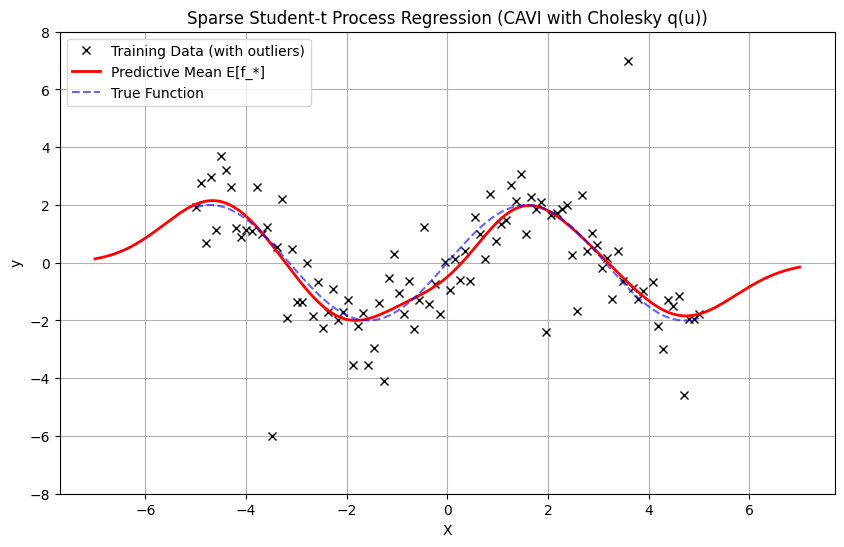

In [4]:
import torch

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionCAVI:
    """
    PyTorch implementation of CAVI for Student-t Process Regression.

    This version uses Cholesky decomposition for numerical stability and
    parameterizes the variational covariance q(u) via its Cholesky factor L_u.
    """
    def __init__(self, X, y, M=20, nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0):
        """
        Initializes the model and variational parameters. [cite: 133]

        Args:
            X (torch.Tensor): Training inputs (N x D).
            y (torch.Tensor): Training outputs (N x 1).
            M (int): Number of inducing points.
            nu_f (float): Degrees of freedom for the TP prior. [cite: 13]
            nu_epsilon (float): Degrees of freedom for the likelihood. [cite: 19]
            sigma_sq (float): Scale parameter for the likelihood noise. [cite: 19]
        """
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # Initialize hyperparameters [cite: 133]
        self.nu_f = torch.tensor(nu_f)
        self.nu_epsilon = torch.tensor(nu_epsilon)
        self.sigma_sq = torch.tensor(sigma_sq)
        self.kernel = rbf_kernel

        # Initialize inducing points Z by selecting M random points from X
        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        # Pre-compute kernel matrices
        self.K_ZZ = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        self.L_ZZ = torch.linalg.cholesky(self.K_ZZ)
        self.K_XZ = self.kernel(self.X, self.Z)
        
        # --- Initialize Variational Parameters --- [cite: 133]
        # q(u) = N(m_u, L_u @ L_u.T)
        self.m_u = torch.zeros(self.M, 1) # [cite: 47]
        # --- MODIFIED: Store Cholesky factor of S_u directly ---
        self.L_u = torch.eye(self.M)       # S_u = L_u @ L_u.T

        # q(r) = Gamma(alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0) # [cite: 49]
        self.beta_r = torch.tensor(1.0)  # [cite: 49]

        # q(lambda_i) = Gamma(alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N) # [cite: 51]
        self.beta_lambda = torch.ones(self.N)  # [cite: 51]

    def _update_q_lambda(self):
        """
        Updates the variational parameters for q(lambda_i).
        """
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u

        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r
        
        k_ii = torch.diag(self.kernel(self.X, self.X))
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        # --- MODIFIED: Use self.L_u directly, no need for cholesky(S_u) ---
        # Term 2: diag(K_XZ @ K_ZZ^-1 @ S_u @ K_ZZ^-1 @ K_ZX)
        # S_u is now represented by L_u @ L_u.T
        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        
        var_f = var_f_term1 + var_f_term2
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        self.alpha_lambda = self.nu_epsilon / 2.0 + 0.5
        self.beta_lambda = self.nu_epsilon / 2.0 + (0.5 / self.sigma_sq) * expected_sq_error.clamp(min=1e-9)

    def _update_q_r(self):
        """
        Updates the variational parameters for q(r).
        """
        # --- MODIFIED: Reconstruct S_u from L_u ---
        # 1. Compute E_q(u)[u^T * K_ZZ^-1 * u]
        # E = Tr(K_ZZ^-1 * S_u) + m_u^T * K_ZZ^-1 * m_u
        S_u = self.L_u @ self.L_u.T
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        mean_term = self.m_u.T @ K_ZZ_inv_m_u
        
        expected_u_quadratic_form = trace_term + mean_term

        # 2. Update alpha_r and beta_r
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self):
        """
        Updates the variational parameters m_u and L_u for q(u).
        """
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        E_lambda_div_sigma_sq = expected_lambda / self.sigma_sq

        # Compute Psi = E[r]*K_ZZ + K_ZX*D*K_XZ
        Psi = expected_r * self.K_ZZ + (self.K_XZ.T * E_lambda_div_sigma_sq) @ self.K_XZ
        L_Psi = torch.linalg.cholesky(Psi + torch.eye(self.M) * 1e-9)

        # 1. Update the mean m_u (this calculation remains the same)
        b_prime = self.K_XZ.T @ (E_lambda_div_sigma_sq * self.y)
        m_u_tmp = torch.cholesky_solve(b_prime.unsqueeze(1), L_Psi)
        self.m_u = self.K_ZZ @ m_u_tmp

        # --- MODIFIED: Update the Cholesky factor L_u directly ---
        # The new covariance is S_u = K_ZZ @ Psi^-1 @ K_ZZ.
        # We need to find L_u such that L_u @ L_u.T = K_ZZ @ Psi^-1 @ K_ZZ.
        # Let A = K_ZZ @ L_Psi^-T. Then S_u = A @ A.T.
        # The Cholesky of A @ A.T can be found via QR decomposition of A.T.
        # If A.T = Q @ R, then S_u = (R.T @ Q.T) @ (Q @ R) = R.T @ R.
        # So, L_u = R.T.

        # a) Compute A.T = L_Psi^-1 @ K_ZZ
        # We solve L_Psi @ X = K_ZZ for X, where X = A.T
        A_T = torch.linalg.solve_triangular(L_Psi, self.K_ZZ, upper=False)

        # b) Compute QR decomposition of A.T
        Q, R = torch.linalg.qr(A_T)

        # c) The new Cholesky factor is R.T
        # We enforce a positive diagonal, which is a convention for Cholesky factors.
        # This does not change the product R.T @ R.
        d = torch.diag(R).sign().to(R.dtype)
        d[d==0] = 1.0 # handle zero-diagonal case
        self.L_u = R.T * d


    def fit(self, num_iterations=100, tol=1e-5, verbose=True):
        """
        Runs the CAVI algorithm until convergence. [cite: 132, 164]
        """
        if verbose:
            print("Starting CAVI optimization...")
            
        for i in range(num_iterations):
            m_u_old = self.m_u.clone()
            
            # --- Perform CAVI updates in sequence ---
            self._update_q_lambda()
            self._update_q_r()
            self._update_q_u()
            
            # Check for convergence
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            
            if verbose:
                print(f"Iteration {i+1}/{num_iterations}, Change in m_u: {change.item():.6f}")

            if change < tol:
                if verbose:
                    print(f"Convergence reached after {i+1} iterations.")
                break
        if verbose:
            print("Optimization finished.")

# Example usage (requires data)
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.set_default_dtype(torch.float64)

    # --- Create synthetic data for demonstration ---
    N_train = 100
    D_dim = 1
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    outlier_noise = torch.distributions.StudentT(df=2.5).sample((N_train, 1)) * 0.8
    y_train = y_true + outlier_noise
    y_train[15] = -6.0
    y_train[85] = 7.0

    # --- Initialize and run the model ---
    model = TPRegressionCAVI(X_train, y_train, M=25, nu_f=5.0, nu_epsilon=5.0, sigma_sq=0.5)
    model.fit(num_iterations=100, tol=1e-6)

    # --- Prediction on test data ---
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    K_test_Z = model.kernel(X_test, model.Z)
    
    # Predictive mean E[f_*] = k(X_*, Z) @ K_ZZ^-1 @ m_u
    K_ZZ_inv_m_u = torch.cholesky_solve(model.m_u, model.L_ZZ)
    pred_mean = K_test_Z @ K_ZZ_inv_m_u

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(X_train, y_train, 'kx', label='Training Data (with outliers)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean E[f_*]')
    plt.plot(X_train, y_true, 'b--', alpha=0.6, label='True Function')
    plt.title('Sparse Student-t Process Regression (CAVI with Cholesky q(u))')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.ylim(-8, 8)
    plt.show()

Starting CAVI optimization...
Iteration 1/100, Change in m_u: 7251383640.889126
ELBO: -385.436627
Iteration 2/100, Change in m_u: 0.140687
ELBO: -305.982679
Iteration 3/100, Change in m_u: 0.071076
ELBO: -246.181166
Iteration 4/100, Change in m_u: 0.032042
ELBO: -260.057895
Iteration 5/100, Change in m_u: 0.019115
ELBO: -275.436589
Iteration 6/100, Change in m_u: 0.024355
ELBO: -289.510047
Iteration 7/100, Change in m_u: 0.028320
ELBO: -301.690697
Iteration 8/100, Change in m_u: 0.026997
ELBO: -311.608258
Iteration 9/100, Change in m_u: 0.021854
ELBO: -319.083761
Iteration 10/100, Change in m_u: 0.015470
ELBO: -324.238041
Iteration 11/100, Change in m_u: 0.009889
ELBO: -327.508304
Iteration 12/100, Change in m_u: 0.005900
ELBO: -329.456668
Iteration 13/100, Change in m_u: 0.003374
ELBO: -330.571000
Iteration 14/100, Change in m_u: 0.001882
ELBO: -331.193126
Iteration 15/100, Change in m_u: 0.001036
ELBO: -331.535788
Iteration 16/100, Change in m_u: 0.000566
ELBO: -331.723133
Iteration 

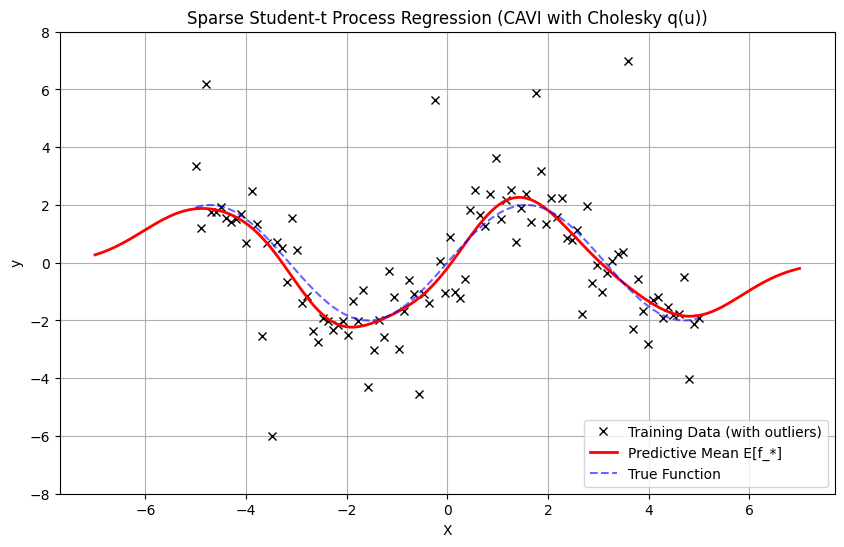

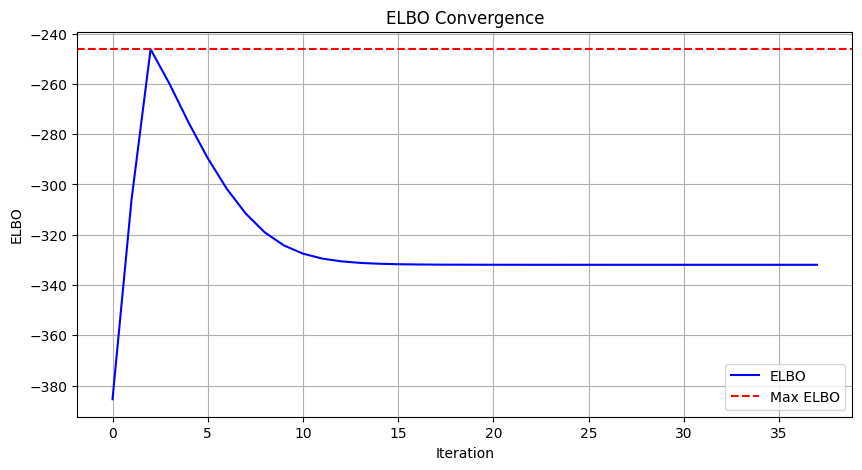

In [8]:
import torch

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionCAVI:
    """
    PyTorch implementation of CAVI for Student-t Process Regression.

    This version uses Cholesky decomposition for numerical stability and
    parameterizes the variational covariance q(u) via its Cholesky factor L_u.
    """
    def __init__(self, X, y, M=20, nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0):
        """
        Initializes the model and variational parameters. [cite: 133]

        Args:
            X (torch.Tensor): Training inputs (N x D).
            y (torch.Tensor): Training outputs (N x 1).
            M (int): Number of inducing points.
            nu_f (float): Degrees of freedom for the TP prior. [cite: 13]
            nu_epsilon (float): Degrees of freedom for the likelihood. [cite: 19]
            sigma_sq (float): Scale parameter for the likelihood noise. [cite: 19]
        """
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # Initialize hyperparameters [cite: 133]
        self.nu_f = torch.tensor(nu_f)
        self.nu_epsilon = torch.tensor(nu_epsilon)
        self.sigma_sq = torch.tensor(sigma_sq)
        self.kernel = rbf_kernel

        # Initialize inducing points Z by selecting M random points from X
        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        # Pre-compute kernel matrices
        self.K_ZZ = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        self.L_ZZ = torch.linalg.cholesky(self.K_ZZ)
        self.K_XZ = self.kernel(self.X, self.Z)
        
        # --- Initialize Variational Parameters --- [cite: 133]
        # q(u) = N(m_u, L_u @ L_u.T)
        self.m_u = torch.zeros(self.M, 1) # [cite: 47]
        # --- MODIFIED: Store Cholesky factor of S_u directly ---
        self.L_u = torch.eye(self.M)       # S_u = L_u @ L_u.T

        # q(r) = Gamma(alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0) # [cite: 49]
        self.beta_r = torch.tensor(1.0)  # [cite: 49]

        # q(lambda_i) = Gamma(alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N) # [cite: 51]
        self.beta_lambda = torch.ones(self.N)  # [cite: 51]

    def _update_q_lambda(self):
        """
        Updates the variational parameters for q(lambda_i).
        """
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u

        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r
            print("Warning: alpha_r <= 1, using beta_r as expected_r_inv for stability.")

        k_ii = torch.diag(self.kernel(self.X, self.X))
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        # --- MODIFIED: Use self.L_u directly, no need for cholesky(S_u) ---
        # Term 2: diag(K_XZ @ K_ZZ^-1 @ S_u @ K_ZZ^-1 @ K_ZX)
        # S_u is now represented by L_u @ L_u.T
        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        
        var_f = var_f_term1 + var_f_term2
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        self.alpha_lambda = self.nu_epsilon / 2.0 + 0.5
        self.beta_lambda = self.nu_epsilon / 2.0 + (0.5 / self.sigma_sq) * expected_sq_error.clamp(min=1e-9)

    def _update_q_r(self):
        """
        Updates the variational parameters for q(r).
        """
        # --- MODIFIED: Reconstruct S_u from L_u ---
        # 1. Compute E_q(u)[u^T * K_ZZ^-1 * u]
        # E = Tr(K_ZZ^-1 * S_u) + m_u^T * K_ZZ^-1 * m_u
        S_u = self.L_u @ self.L_u.T
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        mean_term = self.m_u.T @ K_ZZ_inv_m_u
        
        expected_u_quadratic_form = trace_term + mean_term

        # 2. Update alpha_r and beta_r
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self):
        """
        Updates the variational parameters m_u and L_u for q(u).
        """
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        E_lambda_div_sigma_sq = expected_lambda / self.sigma_sq

        # Compute Psi = E[r]*K_ZZ + K_ZX*D*K_XZ
        Psi = expected_r * self.K_ZZ + (self.K_XZ.T * E_lambda_div_sigma_sq) @ self.K_XZ
        L_Psi = torch.linalg.cholesky(Psi + torch.eye(self.M) * 1e-9)

        # 1. Update the mean m_u (this calculation remains the same)
        b_prime = self.K_XZ.T @ (E_lambda_div_sigma_sq * self.y)
        m_u_tmp = torch.cholesky_solve(b_prime.unsqueeze(1), L_Psi)
        self.m_u = self.K_ZZ @ m_u_tmp

        # --- MODIFIED: Update the Cholesky factor L_u directly ---
        # The new covariance is S_u = K_ZZ @ Psi^-1 @ K_ZZ.
        # We need to find L_u such that L_u @ L_u.T = K_ZZ @ Psi^-1 @ K_ZZ.
        # Let A = K_ZZ @ L_Psi^-T. Then S_u = A @ A.T.
        # The Cholesky of A @ A.T can be found via QR decomposition of A.T.
        # If A.T = Q @ R, then S_u = (R.T @ Q.T) @ (Q @ R) = R.T @ R.
        # So, L_u = R.T.

        # a) Compute A.T = L_Psi^-1 @ K_ZZ
        # We solve L_Psi @ X = K_ZZ for X, where X = A.T
        A_T = torch.linalg.solve_triangular(L_Psi, self.K_ZZ, upper=False)

        # b) Compute QR decomposition of A.T
        Q, R = torch.linalg.qr(A_T)

        # c) The new Cholesky factor is R.T
        # We enforce a positive diagonal, which is a convention for Cholesky factors.
        # This does not change the product R.T @ R.
        d = torch.diag(R).sign().to(R.dtype)
        d[d==0] = 1.0 # handle zero-diagonal case
        self.L_u = R.T * d

    def _calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO) using stable Cholesky-based methods.
        ELBO = E[log p(y|...)] - KL(q(u)||p(u|r)) - KL(q(r)||p(r)) - sum(KL(q(λ_i)||p(λ_i)))
        """
        # --- 1. Expected Log-Likelihood: E[log p(y|f,λ)] ---
        # This term re-uses the components from the _update_q_lambda method.
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        # Re-compute expected squared error cleanly
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        k_ii = torch.diag(self.kernel(self.X, self.X))
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        log_lik = -0.5 * self.N * math.log(2 * math.pi) + \
                  0.5 * torch.sum(expected_log_lambda - torch.log(self.sigma_sq)) - \
                  0.5 * torch.sum(expected_lambda / self.sigma_sq * expected_sq_error)

        # --- 2. KL Divergence for u: KL(q(u) || p(u|r)) ---
        # KL = 0.5 * ( E[log det(r*K_ZZ_inv)] - log det(S_u_inv) - M + Tr(S_u * r*K_ZZ_inv) + ... )
        S_u = self.L_u @ self.L_u.T
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r

        # Log determinants from Cholesky factors
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(self.L_u)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(self.L_ZZ)))
        
        # Quadratic/Trace term from _update_q_r
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        mean_term = self.m_u.T @ torch.cholesky_solve(self.m_u, self.L_ZZ)
        
        kl_u = 0.5 * (
            expected_r * (trace_term + mean_term) -
            logdet_S_u + 
            self.M * expected_log_r -
            logdet_K_ZZ -
            self.M
        ).squeeze()

        # --- 3. KL Divergence for r: KL(q(r) || p(r)) ---
        # KL for Gamma distributions: q=Gamma(aq, bq), p=Gamma(ap, bp)
        q_alpha, q_beta = self.alpha_r, self.beta_r
        p_alpha, p_beta = self.nu_f / 2.0, self.nu_f / 2.0
        
        kl_r = (q_alpha - p_alpha) * torch.digamma(q_alpha) - torch.lgamma(q_alpha) + \
               torch.lgamma(p_alpha) + p_alpha * (torch.log(q_beta) - torch.log(p_beta)) + \
               q_alpha * (p_beta - q_beta) / q_beta

        # --- 4. KL Divergence for λ: sum KL(q(λ_i) || p(λ_i)) ---
        q_alpha_l, q_beta_l = self.alpha_lambda, self.beta_lambda
        p_alpha_l, p_beta_l = self.nu_epsilon / 2.0, self.nu_epsilon / 2.0

        kl_lambda_all = (q_alpha_l - p_alpha_l) * torch.digamma(q_alpha_l) - torch.lgamma(q_alpha_l) + \
                        torch.lgamma(p_alpha_l) + p_alpha_l * (torch.log(q_beta_l) - torch.log(p_beta_l)) + \
                        q_alpha_l * (p_beta_l - q_beta_l) / q_beta_l
        kl_lambda = torch.sum(kl_lambda_all)
        
        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, num_iterations=100, tol=1e-5, verbose=True):
        """
        Runs the CAVI algorithm until convergence. [cite: 132, 164]
        """
        if verbose:
            print("Starting CAVI optimization...")

        elbo_history = []
            
        for i in range(num_iterations):
            m_u_old = self.m_u.clone()
            
            # --- Perform CAVI updates in sequence ---
            self._update_q_lambda()
            self._update_q_r()
            self._update_q_u()
            
            # Calculate ELBO for monitoring convergence
            elbo = self._calculate_elbo()
            elbo_history.append(elbo.item())
            # Check for convergence
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            
            if verbose:
                print(f"Iteration {i+1}/{num_iterations}, Change in m_u: {change.item():.6f}")
                print(f"ELBO: {elbo.item():.6f}")

            if change < tol:
                if verbose:
                    print(f"Convergence reached after {i+1} iterations.")
                break
        if verbose:
            print("Optimization finished.")

        return elbo_history


# Example usage (requires data)
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.set_default_dtype(torch.float64)

    # --- Create synthetic data for demonstration ---
    N_train = 100
    D_dim = 1
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    outlier_noise = torch.distributions.StudentT(df=2.5).sample((N_train, 1)) * 0.8
    y_train = y_true + outlier_noise
    y_train[15] = -6.0
    y_train[85] = 7.0

    # --- Initialize and run the model ---
    model = TPRegressionCAVI(X_train, y_train, M=25, nu_f=5.0, nu_epsilon=5.0, sigma_sq=0.5)
    elbo_history = model.fit(num_iterations=100, tol=1e-9)

    # --- Prediction on test data ---
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    K_test_Z = model.kernel(X_test, model.Z)
    
    # Predictive mean E[f_*] = k(X_*, Z) @ K_ZZ^-1 @ m_u
    K_ZZ_inv_m_u = torch.cholesky_solve(model.m_u, model.L_ZZ)
    pred_mean = K_test_Z @ K_ZZ_inv_m_u

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(X_train, y_train, 'kx', label='Training Data (with outliers)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean E[f_*]')
    plt.plot(X_train, y_true, 'b--', alpha=0.6, label='True Function')
    plt.title('Sparse Student-t Process Regression (CAVI with Cholesky q(u))')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.ylim(-8, 8)
    plt.show()

    # --- Visualize ELBO convergence ---
    # Note: The ELBO history is not stored in the current implementation.
    plt.figure(figsize=(10, 5))
    plt.plot(elbo_history, label='ELBO', color='blue')
    plt.title('ELBO Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('ELBO')
    plt.axhline(y=max(elbo_history), color='red', linestyle='--', label='Max ELBO')
    plt.legend()
    plt.grid(True)
    plt.show()


Starting CAVI optimization...
Iteration 1/100, ELBO: -527.8819, Change in m_u: 6636580413.385899
Iteration 2/100, ELBO: -465.3699, Change in m_u: 0.158325
Iteration 3/100, ELBO: -278.9533, Change in m_u: 0.161852
Iteration 4/100, ELBO: -277.9920, Change in m_u: 0.050845
Iteration 5/100, ELBO: -290.7452, Change in m_u: 0.018167
Iteration 6/100, ELBO: -302.9527, Change in m_u: 0.018847
Iteration 7/100, ELBO: -313.3160, Change in m_u: 0.020558
Iteration 8/100, ELBO: -321.6332, Change in m_u: 0.018258
Iteration 9/100, ELBO: -327.9419, Change in m_u: 0.014247
Iteration 10/100, ELBO: -332.4272, Change in m_u: 0.010295
Iteration 11/100, ELBO: -335.4259, Change in m_u: 0.007055
Iteration 12/100, ELBO: -337.3373, Change in m_u: 0.004641
Iteration 13/100, ELBO: -338.5169, Change in m_u: 0.002956
Iteration 14/100, ELBO: -339.2306, Change in m_u: 0.001838
Iteration 15/100, ELBO: -339.6575, Change in m_u: 0.001123
Iteration 16/100, ELBO: -339.9112, Change in m_u: 0.000678
Iteration 17/100, ELBO: -3

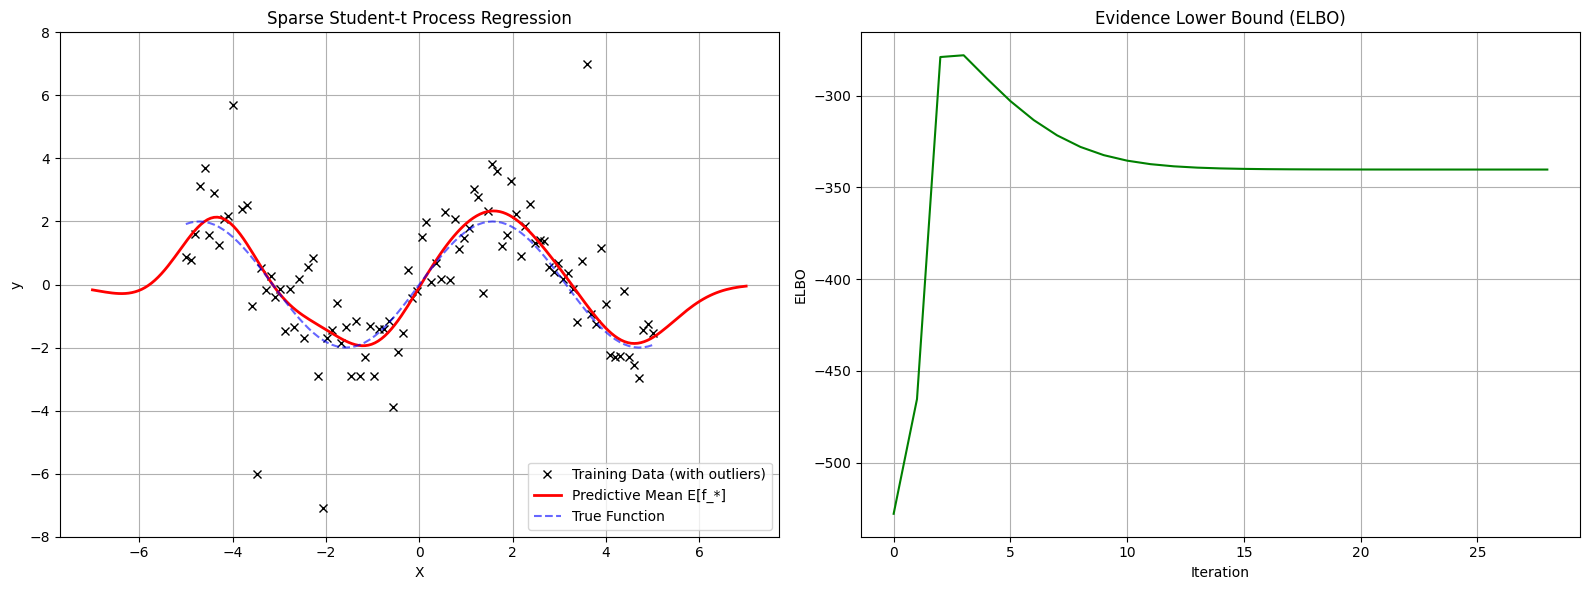

In [ ]:
import torch
import math

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionCAVI:
    """
    PyTorch implementation of CAVI for Student-t Process Regression.

    This version uses Cholesky decomposition for numerical stability,
    parameterizes q(u) via its Cholesky factor L_u, and includes
    a robust ELBO calculation for monitoring convergence.
    """
    def __init__(self, X, y, M=20, nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        self.nu_f = torch.tensor(nu_f)
        self.nu_epsilon = torch.tensor(nu_epsilon)
        self.sigma_sq = torch.tensor(sigma_sq)
        self.kernel = rbf_kernel

        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        self.K_ZZ = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        self.L_ZZ = torch.linalg.cholesky(self.K_ZZ)
        self.K_XZ = self.kernel(self.X, self.Z)
        
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)

        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
        self.elbo_history = []

    def _update_q_lambda(self):
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        k_ii = torch.diag(self.kernel(self.X, self.X))
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        
        var_f = var_f_term1 + var_f_term2
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        self.alpha_lambda = self.nu_epsilon / 2.0 + 0.5
        self.beta_lambda = self.nu_epsilon / 2.0 + (0.5 / self.sigma_sq) * expected_sq_error.clamp(min=1e-9)

    def _update_q_r(self):
        S_u = self.L_u @ self.L_u.T
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        mean_term = self.m_u.T @ K_ZZ_inv_m_u
        
        expected_u_quadratic_form = trace_term + mean_term

        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        E_lambda_div_sigma_sq = expected_lambda / self.sigma_sq

        Psi = expected_r * self.K_ZZ + (self.K_XZ.T * E_lambda_div_sigma_sq) @ self.K_XZ
        L_Psi = torch.linalg.cholesky(Psi + torch.eye(self.M) * 1e-9)

        b_prime = self.K_XZ.T @ (E_lambda_div_sigma_sq * self.y)
        m_u_tmp = torch.cholesky_solve(b_prime.unsqueeze(1), L_Psi)
        self.m_u = self.K_ZZ @ m_u_tmp

        A_T = torch.linalg.solve_triangular(L_Psi, self.K_ZZ, upper=False)
        _Q, R = torch.linalg.qr(A_T)
        d = torch.diag(R).sign().to(R.dtype); d[d==0] = 1.0
        self.L_u = R.T * d

    def _calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO) using stable Cholesky-based methods.
        ELBO = E[log p(y|...)] - KL(q(u)||p(u|r)) - KL(q(r)||p(r)) - sum(KL(q(λ_i)||p(λ_i)))
        """
        # --- 1. Expected Log-Likelihood: E[log p(y|f,λ)] ---
        # This term re-uses the components from the _update_q_lambda method.
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        # Re-compute expected squared error cleanly
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, self.L_ZZ)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        k_ii = torch.diag(self.kernel(self.X, self.X))
        V = torch.linalg.solve_triangular(self.L_ZZ, self.K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        A_T = torch.cholesky_solve(self.K_XZ.T, self.L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        log_lik = -0.5 * self.N * math.log(2 * math.pi) + \
                  0.5 * torch.sum(expected_log_lambda - torch.log(self.sigma_sq)) - \
                  0.5 * torch.sum(expected_lambda / self.sigma_sq * expected_sq_error)

        # --- 2. KL Divergence for u: KL(q(u) || p(u|r)) ---
        # KL = 0.5 * ( E[log det(r*K_ZZ_inv)] - log det(S_u_inv) - M + Tr(S_u * r*K_ZZ_inv) + ... )
        S_u = self.L_u @ self.L_u.T
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r

        # Log determinants from Cholesky factors
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(self.L_u)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(self.L_ZZ)))
        
        # Quadratic/Trace term from _update_q_r
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, self.L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        mean_term = self.m_u.T @ torch.cholesky_solve(self.m_u, self.L_ZZ)
        
        kl_u = 0.5 * (
            expected_r * (trace_term + mean_term) -
            logdet_S_u + 
            self.M * expected_log_r -
            logdet_K_ZZ -
            self.M
        ).squeeze()

        # --- 3. KL Divergence for r: KL(q(r) || p(r)) ---
        # KL for Gamma distributions: q=Gamma(aq, bq), p=Gamma(ap, bp)
        q_alpha, q_beta = self.alpha_r, self.beta_r
        p_alpha, p_beta = self.nu_f / 2.0, self.nu_f / 2.0
        
        kl_r = (q_alpha - p_alpha) * torch.digamma(q_alpha) - torch.lgamma(q_alpha) + \
               torch.lgamma(p_alpha) + p_alpha * (torch.log(q_beta) - torch.log(p_beta)) + \
               q_alpha * (p_beta - q_beta) / q_beta

        # --- 4. KL Divergence for λ: sum KL(q(λ_i) || p(λ_i)) ---
        q_alpha_l, q_beta_l = self.alpha_lambda, self.beta_lambda
        p_alpha_l, p_beta_l = self.nu_epsilon / 2.0, self.nu_epsilon / 2.0

        kl_lambda_all = (q_alpha_l - p_alpha_l) * torch.digamma(q_alpha_l) - torch.lgamma(q_alpha_l) + \
                        torch.lgamma(p_alpha_l) + p_alpha_l * (torch.log(q_beta_l) - torch.log(p_beta_l)) + \
                        q_alpha_l * (p_beta_l - q_beta_l) / q_beta_l
        kl_lambda = torch.sum(kl_lambda_all)
        
        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, num_iterations=100, tol=1e-6, verbose=True):
        if verbose: print("Starting CAVI optimization...")
        self.elbo_history = []
            
        for i in range(num_iterations):
            m_u_old = self.m_u.clone()
            
            self._update_q_lambda()
            self._update_q_r()
            self._update_q_u()
            
            # --- MODIFIED: Calculate ELBO and check for convergence ---
            elbo = self._calculate_elbo()
            self.elbo_history.append(elbo.item())
            
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            
            if verbose:
                print(f"Iteration {i+1}/{num_iterations}, ELBO: {elbo.item():.4f}, Change in m_u: {change.item():.6f}")

            if change < tol:
                if verbose: print(f"Convergence reached after {i+1} iterations.")
                break
        if verbose: print("Optimization finished.")


# Example usage
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.set_default_dtype(torch.float64)

    N_train = 100
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    outlier_noise = torch.distributions.StudentT(df=2.5).sample((N_train, 1)) * 0.8
    y_train = y_true + outlier_noise
    y_train[15] = -6.0
    y_train[85] = 7.0

    model = TPRegressionCAVI(X_train, y_train, M=25, nu_f=5.0, nu_epsilon=5.0, sigma_sq=0.5)
    model.fit(num_iterations=100, tol=1e-6)

    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Prediction
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    K_test_Z = model.kernel(X_test, model.Z)
    K_ZZ_inv_m_u = torch.cholesky_solve(model.m_u, model.L_ZZ)
    pred_mean = K_test_Z @ K_ZZ_inv_m_u
    
    ax1.plot(X_train, y_train, 'kx', label='Training Data (with outliers)')
    ax1.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean E[f_*]')
    ax1.plot(X_train, y_true, 'b--', alpha=0.6, label='True Function')
    ax1.set_title('Sparse Student-t Process Regression')
    ax1.set_xlabel('X')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.grid(True)
    ax1.set_ylim(-8, 8)

    # Plot 2: ELBO
    ax2.plot(model.elbo_history, 'g-')
    ax2.set_title('Evidence Lower Bound (ELBO)')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('ELBO')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

Starting Variational EM optimization...
EM Iter 1/10000, ELBO: -227.3382, LS: 0.500, Var: 1.000, Sigma: 1.000, Nu_f: 3.00, Nu_e: 3.00
EM Iter 2/10000, ELBO: -226.4112, LS: 0.495, Var: 1.010, Sigma: 0.995, Nu_f: 3.03, Nu_e: 3.03
EM Iter 3/10000, ELBO: -225.5016, LS: 0.490, Var: 1.020, Sigma: 0.990, Nu_f: 3.06, Nu_e: 3.06
EM Iter 4/10000, ELBO: -224.6122, LS: 0.485, Var: 1.030, Sigma: 0.985, Nu_f: 3.09, Nu_e: 3.09
EM Iter 5/10000, ELBO: -223.7437, LS: 0.480, Var: 1.041, Sigma: 0.980, Nu_f: 3.12, Nu_e: 3.12
EM Iter 6/10000, ELBO: -222.8967, LS: 0.476, Var: 1.051, Sigma: 0.975, Nu_f: 3.15, Nu_e: 3.15
EM Iter 7/10000, ELBO: -222.0714, LS: 0.471, Var: 1.062, Sigma: 0.970, Nu_f: 3.19, Nu_e: 3.18
EM Iter 8/10000, ELBO: -221.2681, LS: 0.466, Var: 1.072, Sigma: 0.966, Nu_f: 3.22, Nu_e: 3.22
EM Iter 9/10000, ELBO: -220.4869, LS: 0.462, Var: 1.083, Sigma: 0.961, Nu_f: 3.25, Nu_e: 3.25
EM Iter 10/10000, ELBO: -219.7277, LS: 0.457, Var: 1.094, Sigma: 0.956, Nu_f: 3.28, Nu_e: 3.28
EM Iter 11/10000, E

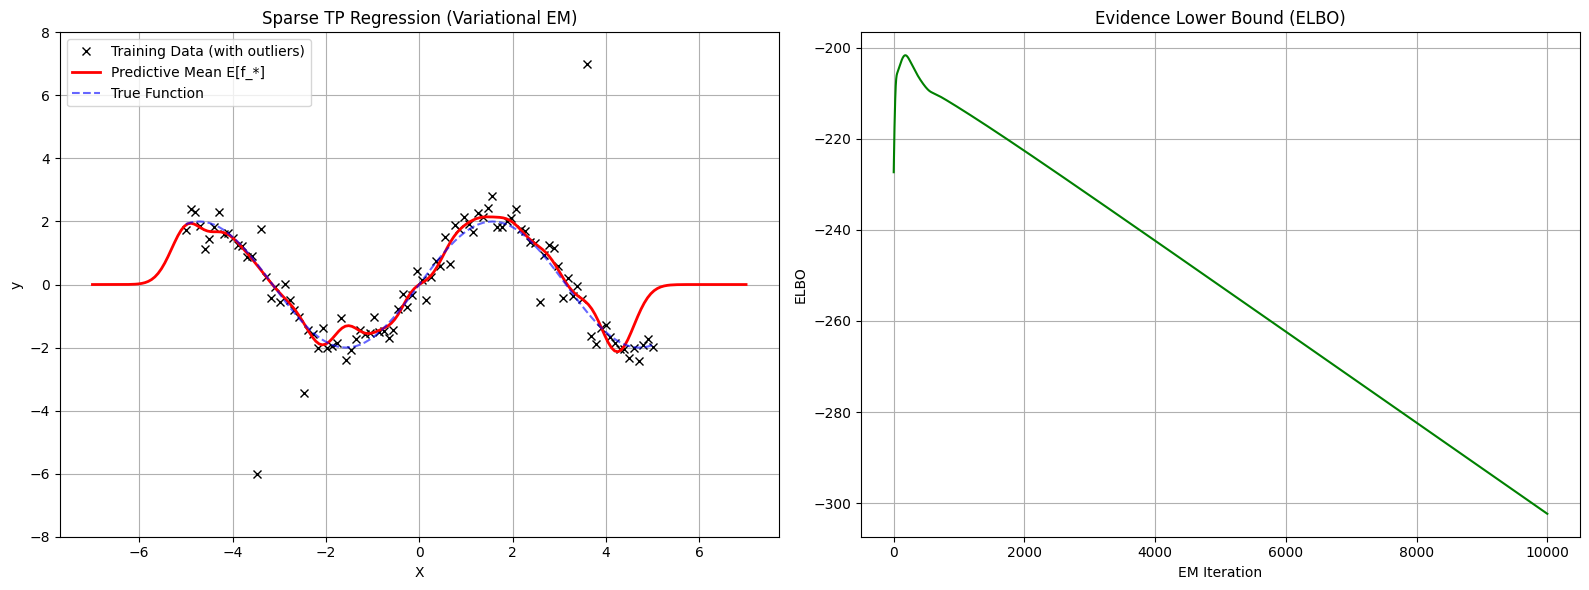

In [16]:
import torch
import torch.nn as nn
import math

# A placeholder for a kernel function (e.g., RBF)
# Now takes hyperparameters as arguments
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

# --- MODIFIED: Inherit from nn.Module for hyperparameter optimization ---
class TPRegressionCAVI(nn.Module):
    """
    PyTorch implementation of Variational EM for Student-t Process Regression.

    - E-Step: CAVI updates for variational parameters (q(u), q(r), q(lambda)).
    - M-Step: Gradient-based optimization of model hyperparameters to maximize the ELBO.
    """
    def __init__(self, X, y, M=20, 
                 # --- MODIFIED: Provide initial values for learnable hyperparameters ---
                 nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0):
        super().__init__()

        # --- MODIFIED: Register data as buffers, not parameters ---
        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape
        self.M = M

        # --- MODIFIED: Hyperparameters are now learnable log-parameters ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(sigma_sq)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_epsilon)))

        # Initialize inducing points Z (fixed for simplicity, but could also be learned)
        indices = torch.randperm(self.N)[:self.M]
        self.register_buffer('Z', self.X[indices].clone())

        # --- Variational Parameters (not nn.Parameters, updated by CAVI) ---
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
        self.elbo_history = []

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            'lengthscale': torch.exp(self.log_kernel_lengthscale),
            'variance': torch.exp(self.log_kernel_variance),
            'sigma_sq': torch.exp(self.log_sigma_sq),
            'nu_f': torch.exp(self.log_nu_f),
            'nu_epsilon': torch.exp(self.log_nu_epsilon),
        }

    def _compute_kernels(self, params):
        """Computes kernel matrices based on current hyperparameters."""
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        return K_ZZ, L_ZZ, K_XZ

    # --- CAVI update methods now take kernel matrices as input ---
    def _update_q_lambda(self, L_ZZ, K_XZ, params):
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        V = torch.linalg.solve_triangular(L_ZZ, K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        A_T = torch.cholesky_solve(K_XZ.T, L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        
        var_f = var_f_term1 + var_f_term2
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
        self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error.clamp(min=1e-9)

    def _update_q_r(self, L_ZZ, params):
        S_u = self.L_u @ self.L_u.T
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ K_ZZ_inv_m_u
        
        expected_u_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, K_ZZ, K_XZ, params):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        E_lambda_div_sigma_sq = expected_lambda / params['sigma_sq']

        Psi = expected_r * K_ZZ + (K_XZ.T * E_lambda_div_sigma_sq) @ K_XZ
        L_Psi = torch.linalg.cholesky(Psi + torch.eye(self.M) * 1e-9)

        b_prime = K_XZ.T @ (E_lambda_div_sigma_sq * self.y)
        m_u_tmp = torch.cholesky_solve(b_prime.unsqueeze(1), L_Psi)
        self.m_u = K_ZZ @ m_u_tmp

        A_T = torch.linalg.solve_triangular(L_Psi, K_ZZ, upper=False)
        _Q, R = torch.linalg.qr(A_T)
        d = torch.diag(R).sign().to(R.dtype); d[d==0] = 1.0
        self.L_u = R.T * d

    def _cavi_e_step(self, cavi_max_iter, cavi_tol):
        """The E-step: runs CAVI until convergence for fixed hyperparameters."""
        params = self._get_hyperparams()
        K_ZZ, L_ZZ, K_XZ = self._compute_kernels(params)

        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()
            
            self._update_q_lambda(L_ZZ, K_XZ, params)
            self._update_q_r(L_ZZ, params)
            self._update_q_u(K_ZZ, K_XZ, params)
            
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break
    
    def _calculate_elbo(self, K_ZZ, L_ZZ, K_XZ, params):
        """Calculates the ELBO for the M-step."""
        # 1. Expected Log-Likelihood
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
        V = torch.linalg.solve_triangular(L_ZZ, K_XZ.T, upper=False)
        var_f_diag_prior = (V**2).sum(dim=0)
        var_f_term1 = expected_r_inv * (k_ii - var_f_diag_prior)

        A_T = torch.cholesky_solve(K_XZ.T, L_ZZ)
        B = A_T.T @ self.L_u
        var_f_term2 = (B**2).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        log_lik = -0.5 * self.N * math.log(2 * math.pi) + \
                  0.5 * torch.sum(expected_log_lambda - torch.log(params['sigma_sq'])) - \
                  0.5 * torch.sum(expected_lambda / params['sigma_sq'] * expected_sq_error)
        
        # 2. KL Divergences
        S_u = self.L_u @ self.L_u.T
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(self.L_u)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        K_ZZ_inv_S_u = torch.cholesky_solve(S_u, L_ZZ)
        trace_term = torch.trace(K_ZZ_inv_S_u)
        mean_term = self.m_u.T @ torch.cholesky_solve(self.m_u, L_ZZ)
        kl_u = 0.5 * (expected_r * (trace_term + mean_term) - logdet_S_u + self.M * expected_log_r - logdet_K_ZZ - self.M).squeeze()

        p_alpha, p_beta = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + \
               torch.lgamma(p_alpha) + p_alpha * (torch.log(self.beta_r) - torch.log(p_beta)) + \
               self.alpha_r * (p_beta - self.beta_r) / self.beta_r

        p_alpha_l, p_beta_l = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_all = (self.alpha_lambda - p_alpha_l) * torch.digamma(self.alpha_lambda) - torch.lgamma(self.alpha_lambda) + \
                        torch.lgamma(p_alpha_l) + p_alpha_l * (torch.log(self.beta_lambda) - torch.log(p_beta_l)) + \
                        self.alpha_lambda * (p_beta_l - self.beta_lambda) / self.beta_lambda
        kl_lambda = torch.sum(kl_lambda_all)
        
        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, num_em_iterations=50, cavi_max_iter=20, cavi_tol=1e-5, lr=0.01, verbose=True):
        """Runs the Variational EM algorithm."""
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        self.elbo_history = []

        if verbose: print("Starting Variational EM optimization...")
            
        for i in range(num_em_iterations):
            # --- E-Step: Update variational parameters with no gradient tracking ---
            with torch.no_grad():
                self._cavi_e_step(cavi_max_iter, cavi_tol)

            # --- M-Step: Update hyperparameters via gradient ascent on the ELBO ---
            optimizer.zero_grad()
            
            # Recompute kernels and ELBO to build the computation graph for this step
            params = self._get_hyperparams()
            K_ZZ, L_ZZ, K_XZ = self._compute_kernels(params)
            neg_elbo = -self._calculate_elbo(K_ZZ, L_ZZ, K_XZ, params)
            
            # Backpropagate and update hyperparameters
            neg_elbo.backward()
            optimizer.step()
            
            self.elbo_history.append(-neg_elbo.item())
            
            if verbose:
                print(f"EM Iter {i+1}/{num_em_iterations}, ELBO: {-neg_elbo.item():.4f}, "
                      f"LS: {params['lengthscale']:.3f}, Var: {params['variance']:.3f}, "
                      f"Sigma: {params['sigma_sq']**0.5:.3f}, Nu_f: {params['nu_f']:.2f}, Nu_e: {params['nu_epsilon']:.2f}")
        
        if verbose: print("Optimization finished.")

    def predict(self, X_test):
        """Make predictions at new test points using the final learned parameters."""
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ, L_ZZ, K_XZ = self._compute_kernels(params)
            
            K_test_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            
            # Predictive mean E[f_*] = k(X_*, Z) @ K_ZZ^-1 @ m_u
            K_ZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_test_Z @ K_ZZ_inv_m_u
            return pred_mean

# Example usage
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.set_default_dtype(torch.float64)

    N_train = 100
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    outlier_noise = torch.distributions.StudentT(df=2.5).sample((N_train, 1)) * 0.3
    y_train = y_true + outlier_noise
    y_train[15] = -6.0
    y_train[85] = 7.0

    model = TPRegressionCAVI(
        X_train, y_train, M=25,
        nu_f=3.0, nu_epsilon=3.0, sigma_sq=1.0, 
        kernel_lengthscale=0.5, kernel_variance=1.0
    )
    model.fit(num_em_iterations=10000, cavi_max_iter=15, lr=0.01)

    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Prediction
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    pred_mean = model.predict(X_test)
    
    ax1.plot(X_train, y_train, 'kx', label='Training Data (with outliers)')
    ax1.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean E[f_*]')
    ax1.plot(X_train, y_true, 'b--', alpha=0.6, label='True Function')
    ax1.set_title('Sparse TP Regression (Variational EM)')
    ax1.set_xlabel('X'); ax1.set_ylabel('y')
    ax1.legend(); ax1.grid(True); ax1.set_ylim(-8, 8)

    # Plot 2: ELBO
    ax2.plot(model.elbo_history, 'g-')
    ax2.set_title('Evidence Lower Bound (ELBO)')
    ax2.set_xlabel('EM Iteration'); ax2.set_ylabel('ELBO')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()